In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

In [ ]:
# Dataset Load
df = pd.read_csv('diabetes_dataset.csv')

# Primary target
target_col = 'diagnosed_diabetes'


leaky_cols = ['diabetes_risk_score', 'diabetes_stage', target_col]

# Pure Features (X) and Target (y)
X = df.drop(columns=[col for col in leaky_cols if col in df.columns])
y = df[target_col]

# Categorical Features Encoding
categorical_cols = X.select_dtypes(include=['object', 'string', 'category']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


zero_cols = ['glucose_fasting', 'glucose_postprandial', 'insulin_level', 'bmi', 'hba1c', 'systolic_bp', 'diastolic_bp']
zero_cols = [col for col in zero_cols if col in X.columns]
X[zero_cols] = X[zero_cols].replace(0, np.nan)

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features count after dropping leaks: {X_train.shape[1]}")

Features count after dropping leaks: 40


In [5]:
# Calculate imbalance ratio
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# Leak-Free Imbalanced Pipeline
pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('resampler', SMOTETomek(random_state=42)),
    ('classifier', XGBClassifier(
        scale_pos_weight=ratio,
        eval_metric='logloss',
        random_state=42
    ))
])

# Train Model
pipeline.fit(X_train, y_train)
print("Pipeline trained successfully!")

Pipeline trained successfully!


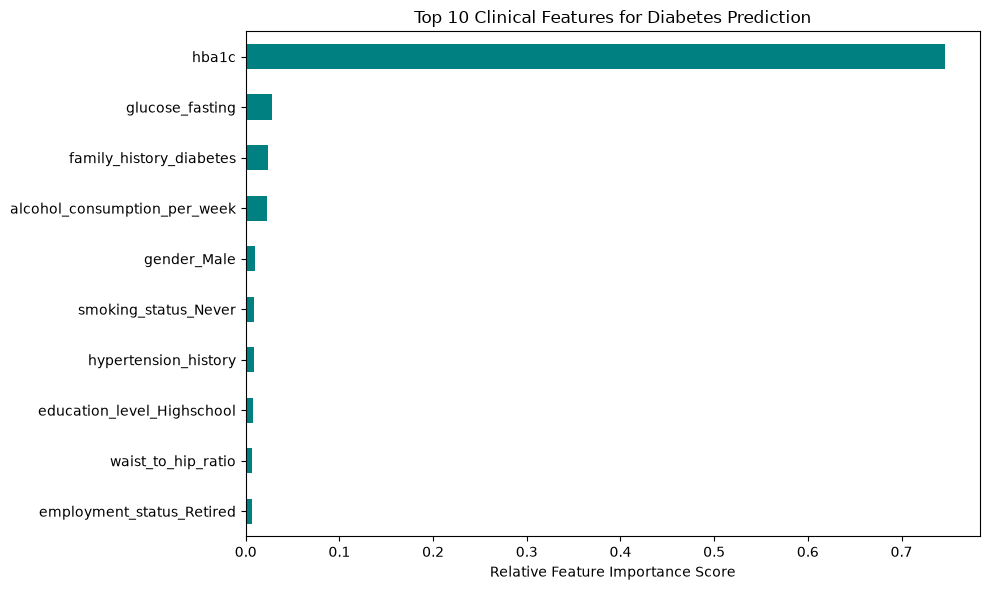

In [6]:
import matplotlib.pyplot as plt

# Extract feature importances from trained XGBoost model
classifier = pipeline.named_steps['classifier']
feature_names = X.columns
importances = classifier.feature_importances_

# Create pandas series for visualization
feat_importances = pd.Series(importances, index=feature_names)
top_features = feat_importances.nlargest(10)

# Plot top 10 clinical predictors
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='teal')
plt.title('Top 10 Clinical Features for Diabetes Prediction')
plt.xlabel('Relative Feature Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [7]:
# Predict Probabilities
y_probs = pipeline.predict_proba(X_test)[:, 1]

# Medical Threshold Tuning for High Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
f2_scores = [(5 * p * r) / (4 * p + r + 1e-10) for p, r in zip(precision, recall)]
best_threshold = thresholds[np.argmax(f2_scores)] if len(thresholds) > 0 else 0.5

y_pred = (y_probs >= best_threshold).astype(int)

# Print Detailed Reports
print(f"Optimal Decision Threshold: {best_threshold:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"True Negatives: {cm[0][0]} | False Positives: {cm[0][1]}")
print(f"False Negatives (Missed Cases): {cm[1][0]} | True Positives (Detected): {cm[1][1]}")

Optimal Decision Threshold: 0.1268

              precision    recall  f1-score   support

 No Diabetes       0.85      0.71      0.77      8000
    Diabetes       0.83      0.92      0.87     12000

    accuracy                           0.83     20000
   macro avg       0.84      0.81      0.82     20000
weighted avg       0.84      0.83      0.83     20000

Confusion Matrix:
True Negatives: 5679 | False Positives: 2321
False Negatives (Missed Cases): 998 | True Positives (Detected): 11002


In [ ]:
import joblib


joblib.dump(pipeline, 'diabetes_xgboost_pipeline.pkl')
print("Model successfully saved as 'diabetes_xgboost_pipeline.pkl'!")

Model successfully saved as 'diabetes_xgboost_pipeline.pkl'!


In [ ]:
import joblib
import os

# Exact path force-save
target_path = r'C:\Users\win10\Downloads\archive (3)\diabetes_xgboost_pipeline.pkl'
joblib.dump(pipeline, target_path)

if os.path.exists(target_path):
    print("✅ FILE CONFIRMED SAVED AT LOCATION!")
else:
    print("❌ File not saved .")

✅ FILE CONFIRMED SAVED AT LOCATION!


In [10]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Test dataset par predictions
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Accuracy check
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"📊 Model Accuracy: {acc * 100:.2f}%")
print(f"📈 ROC-AUC Score: {auc * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

📊 Model Accuracy: 91.88%
📈 ROC-AUC Score: 94.14%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 7972    28]
 [ 1596 10404]]
